In [ ]:
!pip install ucimlrepo

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
adult = fetch_ucirepo(id=2)

X = adult.data.features
y = adult.data.targets

df = pd.concat([X, y], axis=1)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (48842, 15)


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,47879,9,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,47876,15,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Missing values represented by '?':")

for col in df.columns:
    count = df[col].astype(str).str.strip().eq("?").sum()
    print(col, ":", count)

Missing values represented by '?':
age : 0
workclass : 1836
fnlwgt : 0
education : 0
education-num : 0
marital-status : 0
occupation : 1843
relationship : 0
race : 0
sex : 0
capital-gain : 0
capital-loss : 0
hours-per-week : 0
native-country : 583
income : 0


In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = df[col].str.strip()

df = df.replace("?", np.nan)

print("Missing values after conversion:")
print(df.isna().sum())

Missing values after conversion:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
income               0
dtype: int64


In [ ]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 29


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (48813, 15)


In [ ]:
print("Age range:")
print("Minimum:", df["age"].min())
print("Maximum:", df["age"].max())

print("\nHours per week range:")
print("Minimum:", df["hours-per-week"].min())
print("Maximum:", df["hours-per-week"].max())

Age range:
Minimum: 17
Maximum: 90

Hours per week range:
Minimum: 1
Maximum: 99


In [ ]:
invalid_age = (df["age"] < 17) | (df["age"] > 100)
invalid_hours = (df["hours-per-week"] < 0) | (df["hours-per-week"] > 168)

print("Invalid age records:", invalid_age.sum())
print("Invalid hours-per-week records:", invalid_hours.sum())

Invalid age records: 0
Invalid hours-per-week records: 0


In [ ]:
for col in cat_cols:
    print("\n", col)
    print(df[col].value_counts(dropna=False).head(10))


 workclass
workclass
Private             33879
Self-emp-not-inc     3861
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1694
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

 education
education
HS-grad         15777
Some-college    10869
Bachelors        8020
Masters          2656
Assoc-voc        2060
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           954
Prof-school       834
Name: count, dtype: int64

 marital-status
marital-status
Married-civ-spouse       22372
Never-married            16098
Divorced                  6630
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

 occupation
occupation
Prof-specialty       6167
Craft-repair         6107
Exec-managerial      6084
Adm-clerical         5608
Sales                5504
Other-service        

In [ ]:
def iqr_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (data[column] < lower) | (data[column] > upper)

    return mask, lower, upper


numeric_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

for col in numeric_cols:
    mask, lower, upper = iqr_outliers(df, col)

    print(
        col,
        "→ Outliers:", mask.sum(),
        "| Lower:", round(lower, 2),
        "| Upper:", round(upper, 2)
    )

age → Outliers: 215 | Lower: -2.0 | Upper: 78.0
fnlwgt → Outliers: 1453 | Lower: -62542.5 | Upper: 417717.5
education-num → Outliers: 1789 | Lower: 4.5 | Upper: 16.5
capital-gain → Outliers: 4035 | Lower: 0.0 | Upper: 0.0
capital-loss → Outliers: 2282 | Lower: 0.0 | Upper: 0.0
hours-per-week → Outliers: 13489 | Lower: 32.5 | Upper: 52.5


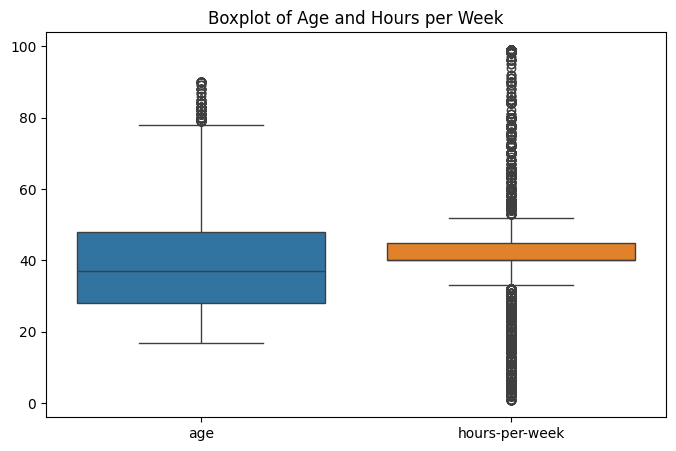

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df[["age", "hours-per-week"]])

plt.title("Boxplot of Age and Hours per Week")
plt.show()

In [ ]:
df.loc[invalid_age, "age"] = np.nan
df.loc[invalid_hours, "hours-per-week"] = np.nan

print("Invalid values handled.")

Invalid values handled.


In [ ]:
df["income"] = df["income"].str.strip()

X = df.drop("income", axis=1)

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (48813, 14)
Target shape: (48813,)


In [ ]:
df["income"] = df["income"].astype(str).str.strip()

X = df.drop("income", axis=1)

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget values:")
print(y.value_counts())

Features shape: (48813, 14)
Target shape: (48813,)

Target values:
income
0.0    24698
1.0     7839
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Ensure the 'income' column in 'df' is correctly cleaned
# Strip whitespace and any trailing dots
df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")

# Create a temporary target variable 'y_temp' from the cleaned 'income' column
y_temp = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Identify valid rows where 'y_temp' is not NaN
valid_indices = y_temp.notna()

# Filter the original dataframe 'df' and the temporary 'y_temp'
# This ensures X and y align and are free of NaNs in y
df_filtered = df[valid_indices].reset_index(drop=True)
y_filtered = y_temp[valid_indices].reset_index(drop=True)

# Now, create X by dropping the 'income' column from the filtered dataframe
X_filtered = df_filtered.drop("income", axis=1)

# Perform the train-test split with the cleaned X and y
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_filtered,
    test_size=0.20,
    random_state=42,
    stratify=y_filtered
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (39050, 14)
Testing data: (9763, 14)


In [ ]:
# Check the actual income values
print(df["income"].value_counts(dropna=False))

income
<=50K    37128
>50K     11685
Name: count, dtype: int64


In [ ]:
# Clean the income column
df["income"] = df["income"].astype(str).str.strip().str.rstrip(".")

# Convert income labels into 0 and 1
y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

# Remove rows where target is still missing
valid = y.notna()

X = X.loc[valid].reset_index(drop=True)
y = y.loc[valid].reset_index(drop=True)

print("Missing values in y:", y.isna().sum())
print("Target values:")
print(y.value_counts())

Missing values in y: 0
Target values:
income
0    37128
1    11685
Name: count, dtype: int64


In [ ]:
numeric_features = X_train.select_dtypes(include=np.number).columns
categorical_features = X_train.select_dtypes(include="object").columns

print("Numerical columns:")
print(list(numeric_features))

print("\nCategorical columns:")
print(list(categorical_features))

Numerical columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical columns:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Numerical preprocessing pipeline created successfully.")

Numerical preprocessing pipeline created successfully.


In [ ]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

print("Categorical preprocessing pipeline created successfully.")

Categorical preprocessing pipeline created successfully.


In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Complete preprocessing pipeline created successfully.")

Complete preprocessing pipeline created successfully.


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Processed training data:", X_train_processed.shape)
print("Processed testing data:", X_test_processed.shape)

Processed training data: (39050, 105)
Processed testing data: (9763, 105)


In [ ]:
print("Missing values in the dataset:")
print(df.isna().sum())

Missing values in the dataset:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     856
income               0
dtype: int64


In [ ]:
print("FINAL PREPROCESSING RESULT ")

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

print("\nPreprocessing completed successfully!")

FINAL PREPROCESSING RESULT 
Training data shape: (39050, 105)
Testing data shape: (9763, 105)

Preprocessing completed successfully!


In [ ]:
print("========== WEEK 1 SUMMARY ==========")

print("Total rows:", len(df))
print("Total columns:", len(df.columns))
print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nData cleaning and preprocessing completed successfully!")

========== WEEK 1 SUMMARY ==========
Total rows: 48813
Total columns: 15
Training rows: 39050
Testing rows: 9763
Numerical features: 6
Categorical features: 8

Data cleaning and preprocessing completed successfully!


In [ ]:
print(df.shape)

(48813, 15)


In [ ]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [ ]:
df_eda = df.copy()

print("EDA dataset created successfully!")
print("Shape:", df_eda.shape)

EDA dataset created successfully!
Shape: (48813, 15)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
df_eda.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [ ]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48813 entries, 0 to 48812
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48813 non-null  float64
 1   workclass       46014 non-null  object 
 2   fnlwgt          48813 non-null  int64  
 3   education       48813 non-null  object 
 4   education-num   48813 non-null  int64  
 5   marital-status  48813 non-null  object 
 6   occupation      46004 non-null  object 
 7   relationship    48813 non-null  object 
 8   race            48813 non-null  object 
 9   sex             48813 non-null  object 
 10  capital-gain    48813 non-null  int64  
 11  capital-loss    48813 non-null  int64  
 12  hours-per-week  48813 non-null  float64
 13  native-country  47957 non-null  object 
 14  income          48813 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
df_eda.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48813.0,NaN,NaN,NaN,38.647348,13.709005,17.0,28.0,37.0,48.0,90.0
workclass,46014,8,Private,33879,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48813.0,NaN,NaN,NaN,189667.904964,105606.24336,12285.0,117555.0,178140.0,237620.0,1490400.0
education,48813,16,HS-grad,15777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48813.0,NaN,NaN,NaN,10.078688,2.570257,1.0,9.0,10.0,12.0,16.0
marital-status,48813,7,Married-civ-spouse,22372,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46004,14,Prof-specialty,6167,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48813,6,Husband,19709,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48813,5,White,41736,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48813,2,Male,32631,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df_eda["income"].value_counts())

income
<=50K    37128
>50K     11685
Name: count, dtype: int64


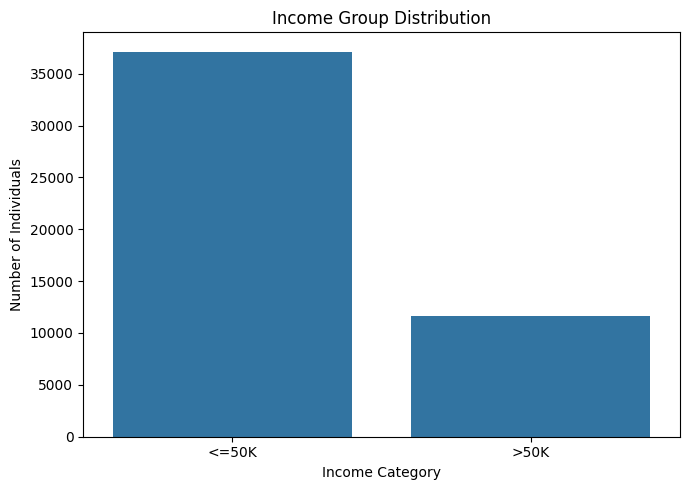

In [ ]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df_eda, x="income")

plt.title("Income Group Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")

plt.tight_layout()
plt.show()

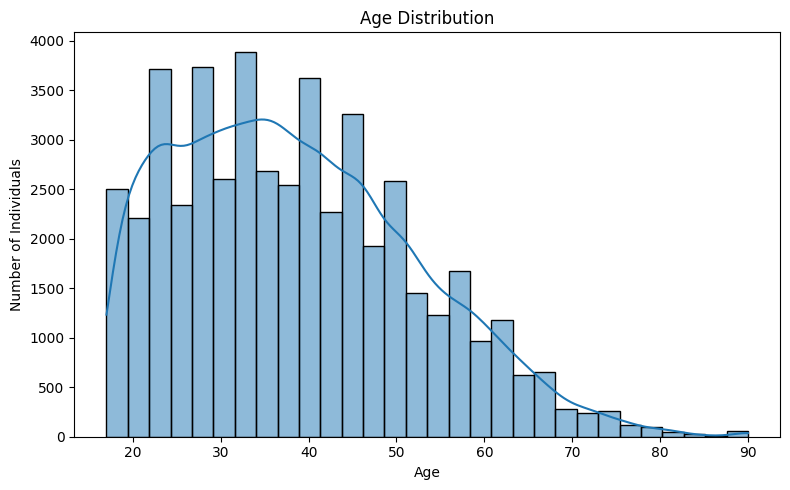

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df_eda, x="age", bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Individuals")

plt.tight_layout()
plt.show()

In [ ]:
education_income = pd.crosstab(
    df_eda["education"],
    df_eda["income"],
    normalize="index"
) * 100

print(education_income.round(2))

income        <=50K   >50K
education                 
10th          93.74   6.26
11th          94.92   5.08
12th          92.68   7.32
1st-4th       96.73   3.27
5th-6th       94.69   5.31
7th-8th       93.50   6.50
9th           94.58   5.42
Assoc-acdm    74.20  25.80
Assoc-voc     74.66  25.34
Bachelors     58.69  41.31
Doctorate     27.44  72.56
HS-grad       84.14  15.86
Masters       45.07  54.93
Preschool     98.78   1.22
Prof-school   26.02  73.98
Some-college  81.03  18.97


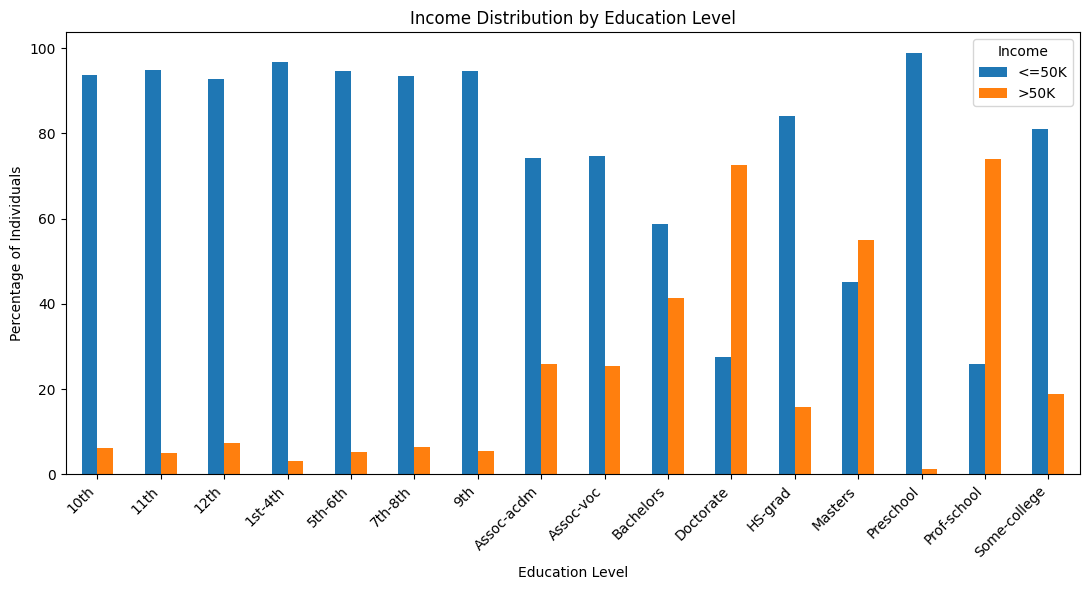

In [ ]:
education_income.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Income Distribution by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")

plt.tight_layout()
plt.show()

In [ ]:
occupation_income = pd.crosstab(
    df_eda["occupation"],
    df_eda["income"],
    normalize="index"
) * 100

print(occupation_income.round(2))

income             <=50K   >50K
occupation                     
Adm-clerical       86.31  13.69
Armed-Forces       66.67  33.33
Craft-repair       77.35  22.65
Exec-managerial    52.20  47.80
Farming-fishing    88.37  11.63
Handlers-cleaners  93.34   6.66
Machine-op-inspct  87.71  12.29
Other-service      95.85   4.15
Priv-house-serv    98.75   1.25
Prof-specialty     54.87  45.13
Protective-serv    68.67  31.33
Sales              73.20  26.80
Tech-support       70.93  29.07
Transport-moving   79.58  20.42


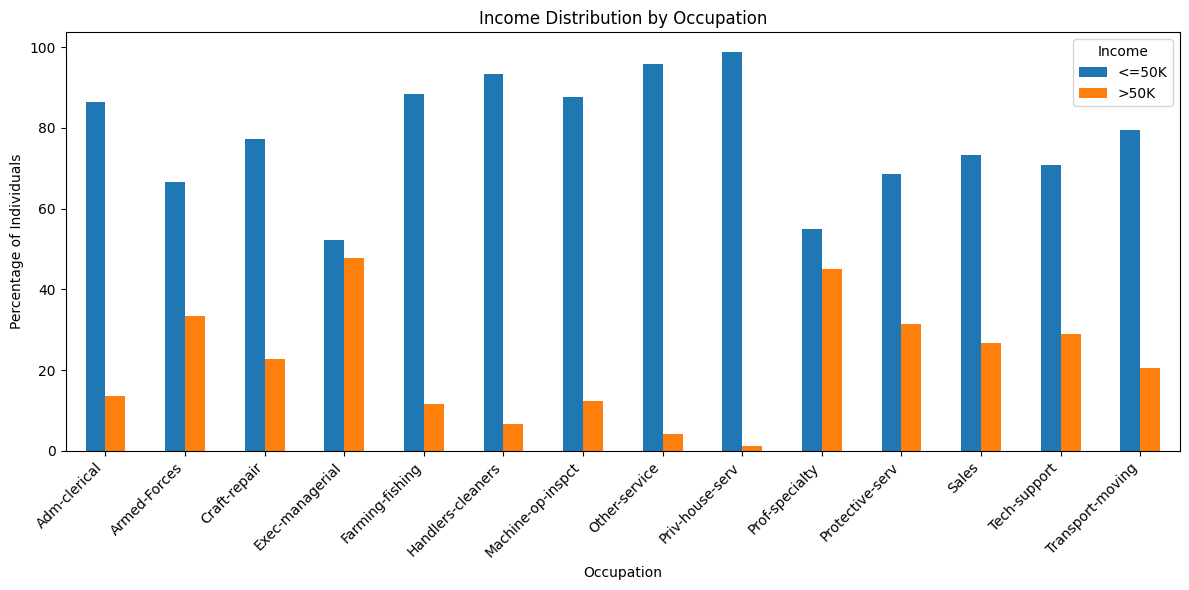

In [ ]:
occupation_income.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Income Distribution by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage of Individuals")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Income")

plt.tight_layout()
plt.show()

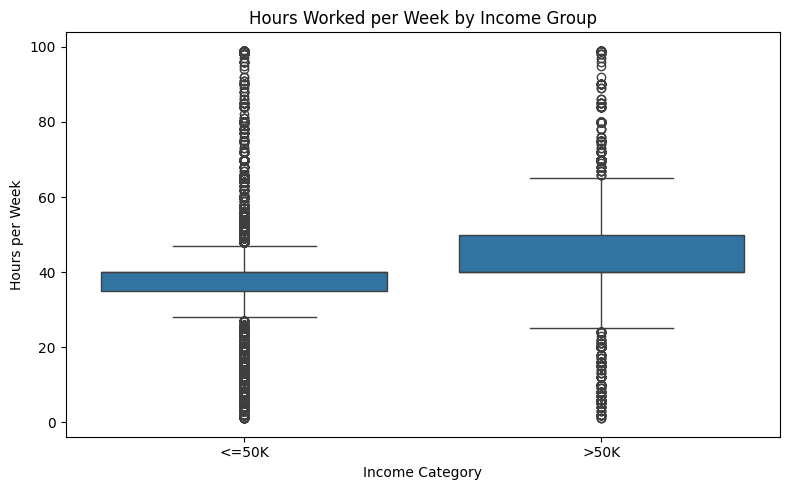

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="income",
    y="hours-per-week"
)

plt.title("Hours Worked per Week by Income Group")
plt.xlabel("Income Category")
plt.ylabel("Hours per Week")

plt.tight_layout()
plt.show()

In [ ]:
numeric_df = df_eda.select_dtypes(include=np.number)

print(numeric_df.columns.tolist())

['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


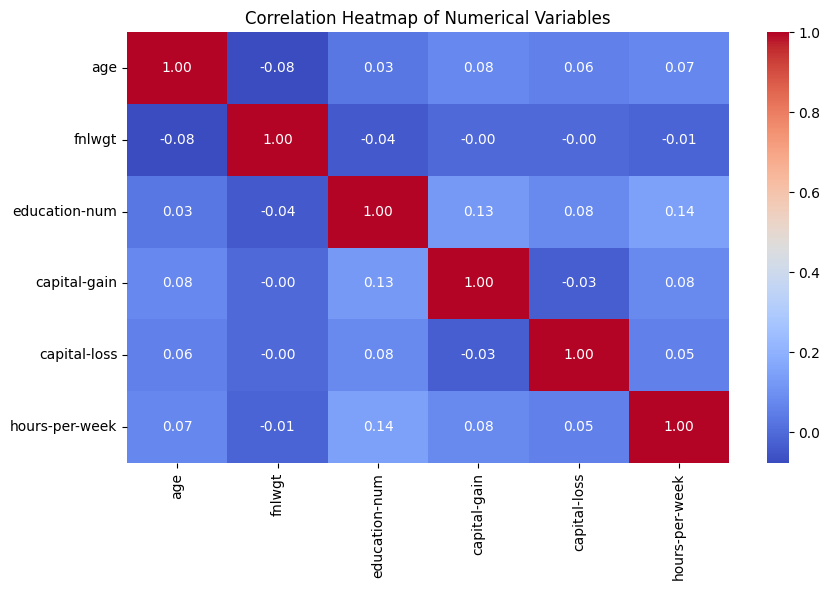

In [ ]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

In [ ]:
group_summary = df_eda.groupby("income").agg(
    average_age=("age", "mean"),
    average_hours=("hours-per-week", "mean"),
    median_age=("age", "median"),
    median_hours=("hours-per-week", "median")
)

print(group_summary.round(2))

        average_age  average_hours  median_age  median_hours
income                                                      
<=50K         36.88          38.84        34.0          40.0
>50K          44.28          45.45        43.0          40.0


In [ ]:
print("EDA completed successfully!")
print("Dataset shape:", df_eda.shape)
print("Number of features:", df_eda.shape[1])
print("Number of records:", df_eda.shape[0])

EDA completed successfully!
Dataset shape: (48813, 15)
Number of features: 15
Number of records: 48813
